In [1]:
# Copyright © 2026 Rioborue Alexander Oghenerume. All rights reserved.
# This code cannot be used, modified, or distributed without permission.
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
STATISTICIAN_BANNER = "© R.A. Oghenerume. All Rights Reserved."
def print_banner():
    line = "=" * 70
    print(line)
    print(STATISTICIAN_BANNER.center(70))
    print(line)
print_banner()

               © R.A. Oghenerume. All Rights Reserved.                


In [2]:
from google.colab import files
uploaded = files.upload()

Saving Forensic.xlsx to Forensic.xlsx


In [3]:
INPUT_FILE  = 'Forensic.xlsx'
OUTPUT_FILE = 'analysis_results.xlsx'

df = pd.read_excel(INPUT_FILE)
print("=" * 70)
print(f"Loaded: {INPUT_FILE}")
print(f"Shape : {df.shape}")
print(f"Columns: {list(df.columns)}")
print("=" * 70)

PREDICTORS = ['AI', 'BCT', 'BDA']
OUTCOME    = 'FFI'

Loaded: Forensic.xlsx
Shape : (384, 24)
Columns: ['AI1', 'AI2', 'AI3', 'AI4', 'AI5', 'BCT1', 'BCT2', 'BCT3', 'BCT4', 'BCT5', 'BDA1', 'BDA2', 'BDA3', 'BDA4', 'BDA5', 'FFI1', 'FFI2', 'FFI3', 'FFI4', 'FFI5', 'AI', 'BCT', 'BDA', 'FFI']


In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)
def pearson_with_ci(x, y, alpha=0.05):
    """Pearson r with p-value, N, and Fisher-z 95% CI (SPSS-style)."""
    r, pval = stats.pearsonr(x, y)
    n = len(x)
    if n > 3:
        z      = np.arctanh(r)
        se     = 1 / np.sqrt(n - 3)
        zcrit  = stats.norm.ppf(1 - alpha / 2)
        lo, hi = np.tanh(z - zcrit * se), np.tanh(z + zcrit * se)
    else:
        lo, hi = np.nan, np.nan
    return r, pval, n, lo, hi


def correlation_tests(df, predictors, outcome):
    rows = []
    for i, p in enumerate(predictors, start=1):
        r, pval, n, lo, hi = pearson_with_ci(df[p], df[outcome])
        strength = ('very high' if abs(r) >= .7 else
                    'high'      if abs(r) >= .5 else
                    'moderate'  if abs(r) >= .3 else 'low')
        rows.append({
            'Hypothesis'  : f'H0{i}',
            'Relationship': f'{p} ↔ {outcome}',
            'N'           : n,
            'r'           : round(r, 3),
            '95% CI'      : f'[{lo:.3f}, {hi:.3f}]',
            'p-value'     : round(pval, 4),
            'Strength'    : strength,
            'Decision'    : 'Reject H0' if pval < .05 else 'Fail to reject H0',
        })
    return pd.DataFrame(rows)

corr_tbl = correlation_tests(df, PREDICTORS, OUTCOME)

print("\n" + "=" * 70)
print("H01–H03: PEARSON CORRELATION ANALYSIS (α = .05)")
print("=" * 70)
print(corr_tbl.to_string(index=False))


H01–H03: PEARSON CORRELATION ANALYSIS (α = .05)
Hypothesis Relationship   N     r         95% CI  p-value Strength  Decision
       H01     AI ↔ FFI 384 0.623 [0.557, 0.680]      0.0     high Reject H0
       H02    BCT ↔ FFI 384 0.505 [0.426, 0.576]      0.0     high Reject H0
       H03    BDA ↔ FFI 384 0.457 [0.374, 0.533]      0.0 moderate Reject H0


In [5]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)
def simple_regressions(df, predictors, outcome):
    rows = []
    for i, p in enumerate(predictors, start=4):
        X = sm.add_constant(df[[p]])
        m = sm.OLS(df[outcome], X).fit()

        ci       = m.conf_int().loc[p]
        beta_std = m.params[p] * df[p].std() / df[outcome].std()
        se_est   = np.sqrt(m.mse_resid)
        dw       = durbin_watson(m.resid)

        rows.append({
            'Hypothesis'  : f'H0{i}',
            'Predictor'   : p,
            'B'           : round(m.params[p], 4),
            'SE'          : round(m.bse[p], 4),
            'Beta'        : round(beta_std, 3),
            '95% CI'      : f'[{ci[0]:.4f}, {ci[1]:.4f}]',
            't'           : round(m.tvalues[p], 3),
            'p-value'     : round(m.pvalues[p], 4),
            'R'           : round(np.sqrt(m.rsquared), 3),
            'R²'          : round(m.rsquared, 3),
            'Adj. R²'     : round(m.rsquared_adj, 3),
            'Std. Error'  : round(se_est, 4),
            'F'           : round(m.fvalue, 3),
            'Prob (F)'    : f'{m.f_pvalue:.3e}',
            'DW'          : round(dw, 3),
            'N'           : int(m.nobs),
            'Decision'    : 'Reject H0' if m.pvalues[p] < .05 else 'Fail to reject H0',
        })
    return pd.DataFrame(rows)

simple_tbl = simple_regressions(df, PREDICTORS, OUTCOME)

print("\n" + "=" * 70)
print("H04–H06: SIMPLE LINEAR REGRESSION (each predictor → FFI)")
print("=" * 70)
print(simple_tbl.to_string(index=False))


H04–H06: SIMPLE LINEAR REGRESSION (each predictor → FFI)
Hypothesis Predictor      B     SE  Beta           95% CI      t  p-value     R    R²  Adj. R²  Std. Error       F  Prob (F)    DW   N  Decision
       H04        AI 0.6399 0.0412 0.623 [0.5590, 0.7208] 15.548      0.0 0.623 0.388    0.386      3.3592 241.748 1.387e-42 1.998 384 Reject H0
       H05       BCT 0.5006 0.0438 0.505 [0.4145, 0.5867] 11.434      0.0 0.505 0.255    0.253      3.7050 130.747 3.067e-26 2.083 384 Reject H0
       H06       BDA 0.4541 0.0452 0.457 [0.3653, 0.5429] 10.051      0.0 0.457 0.209    0.207      3.8173 101.029 3.030e-21 1.935 384 Reject H0


In [6]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 250)
X = sm.add_constant(df[PREDICTORS])
y = df[OUTCOME]
model = sm.OLS(y, X).fit()

print("\n" + "=" * 70)
print("H07: MULTIPLE LINEAR REGRESSION (AI + BCT + BDA → FFI)")
print("=" * 70)

print("\n[Model Summary]")
print(f"    R          = {np.sqrt(model.rsquared):.4f}")
print(f"    R²         = {model.rsquared:.4f}")
print(f"    Adj. R²    = {model.rsquared_adj:.4f}")
print(f"    Std. Error = {np.sqrt(model.mse_resid):.4f}")
print(f"    F({int(model.df_model)}, {int(model.df_resid)})   = {model.fvalue:.3f}")
print(f"    Prob (F)   = {model.f_pvalue:.3e}")
print(f"    Durbin–Watson = {durbin_watson(model.resid):.3f}")
print(f"    N          = {int(model.nobs)}")

sd_pred  = df[PREDICTORS].std()
sd_y     = df[OUTCOME].std()
beta_std = model.params[PREDICTORS] * sd_pred / sd_y

ci = model.conf_int()
ci.columns = ['CI Lower', 'CI Upper']

vifs = {c: variance_inflation_factor(X.values, i)
        for i, c in enumerate(X.columns) if c != 'const'}
tolerance = {c: 1 / v for c, v in vifs.items()}

coef_tbl = pd.DataFrame({
    'B'          : model.params,
    'Std. Error' : model.bse,
    'Beta'       : [np.nan] + beta_std.tolist(),
    't'          : model.tvalues,
    'p-value'    : model.pvalues,
    'CI Lower'   : ci['CI Lower'],
    'CI Upper'   : ci['CI Upper'],
    'Tolerance'  : [np.nan] + [tolerance[p] for p in PREDICTORS],
    'VIF'        : [np.nan] + [vifs[p] for p in PREDICTORS],
    'Zero-order r': [np.nan] + [df[p].corr(df[OUTCOME]) for p in PREDICTORS],
}).round(4)

print("\n[Coefficients]")
print(coef_tbl.to_string())

print("\n[Significance Check]")
for v in PREDICTORS:
    b, p = model.params[v], model.pvalues[v]
    if   p < .001: tag = "p < .001  ✔ (strong)"
    elif p < .04 : tag = "p < .04   ✔ (moderate)"
    else         : tag = "not within target"
    print(f"    {v:5s}  B = {b:+.4f}   p = {p:.4f}   -> {tag}")

eq = f"FFI = {model.params['const']:.3f}"
for v in PREDICTORS:
    eq += f" + {model.params[v]:.3f}({v})"
print(f"\n[Regression Equation]\n    {eq}")

def part_partial(model, df, predictors, outcome):
    """SPSS-style zero-order, partial, and part correlations."""
    R2_full = model.rsquared
    out = {}
    for p in predictors:
        others  = [x for x in predictors if x != p]
        X_red   = sm.add_constant(df[others])
        m_red   = sm.OLS(df[outcome], X_red).fit()
        R2_red  = m_red.rsquared
        part_r  = np.sqrt(max(R2_full - R2_red, 0)) * np.sign(model.params[p])
        partial_r = part_r / np.sqrt(1 - R2_red) if R2_red < 1 else np.nan
        zero_r    = df[p].corr(df[outcome])
        out[p] = {'Zero-order': zero_r, 'Partial': partial_r, 'Part': part_r}
    return pd.DataFrame(out).T.round(4)

pp_tbl = part_partial(model, df, PREDICTORS, OUTCOME)

print("\n[Correlations: Zero-order, Partial, Part]")
print(pp_tbl.to_string())

from numpy.linalg import eig
Xc      = X.drop(columns='const')
Xc_std  = (Xc - Xc.mean()) / Xc.std()
R_mat   = Xc_std.corr().values
eigvals = eig(R_mat)[0]
cond_idx = np.sqrt(eigvals.max() / eigvals)

collin_tbl = pd.DataFrame({
    'Dimension'       : range(1, len(eigvals) + 1),
    'Eigenvalue'      : eigvals,
    'Condition Index' : cond_idx,
}).round(4)

print("\n[Collinearity Diagnostics]")
print(collin_tbl.to_string(index=False))

infl = model.get_influence()
resid_stats = infl.summary_frame()

resid_summary = pd.DataFrame({
    'Minimum' : [model.fittedvalues.min(),
                 model.resid.min(),
                 resid_stats['standard_resid'].min(),
                 resid_stats['cooks_d'].min(),
                 resid_stats['hat_diag'].min()],
    'Maximum' : [model.fittedvalues.max(),
                 model.resid.max(),
                 resid_stats['standard_resid'].max(),
                 resid_stats['cooks_d'].max(),
                 resid_stats['hat_diag'].max()],
    'Mean'    : [model.fittedvalues.mean(),
                 model.resid.mean(),
                 resid_stats['standard_resid'].mean(),
                 resid_stats['cooks_d'].mean(),
                 resid_stats['hat_diag'].mean()],
    'Std. Dev': [model.fittedvalues.std(),
                 model.resid.std(),
                 resid_stats['standard_resid'].std(),
                 resid_stats['cooks_d'].std(),
                 resid_stats['hat_diag'].std()],
    'N'       : int(model.nobs),
}, index=['Predicted Value', 'Residual', 'Std. Residual',
          "Cook's Distance", 'Centered Leverage Value'])

print("\n[Residuals Statistics]")
print(resid_summary.round(4).to_string())

mask    = resid_stats['standard_resid'].abs() > 3
casewise = df.loc[mask].copy()
casewise['Std. Residual'] = resid_stats.loc[mask, 'standard_resid']
casewise['Predicted']     = model.fittedvalues.loc[mask]
casewise['Residual']      = model.resid.loc[mask]

print(f"\n[Casewise Diagnostics] — {len(casewise)} case(s) with |std resid| > 3")
if len(casewise):
    print(casewise[['Std. Residual', 'Predicted', 'Residual']].round(4).to_string())
else:
    print("    None")


H07: MULTIPLE LINEAR REGRESSION (AI + BCT + BDA → FFI)

[Model Summary]
    R          = 0.7315
    R²         = 0.5351
    Adj. R²    = 0.5314
    Std. Error = 2.9345
    F(3, 380)   = 145.783
    Prob (F)   = 7.231e-63
    Durbin–Watson = 1.997
    N          = 384

[Coefficients]
            B  Std. Error    Beta        t  p-value  CI Lower  CI Upper  Tolerance     VIF  Zero-order r
const  0.0168      0.6152     NaN   0.0272   0.9783   -1.1929    1.2264        NaN     NaN           NaN
AI     0.4704      0.0395  0.4576  11.9100   0.0000    0.3927    0.5480     0.8287  1.2066        0.6226
BCT    0.2483      0.0385  0.2505   6.4532   0.0000    0.1726    0.3240     0.8122  1.2313        0.5050
BDA    0.2686      0.0367  0.2705   7.3156   0.0000    0.1964    0.3408     0.8947  1.1177        0.4573

[Significance Check]
    AI     B = +0.4704   p = 0.0000   -> p < .001  ✔ (strong)
    BCT    B = +0.2483   p = 0.0000   -> p < .001  ✔ (strong)
    BDA    B = +0.2686   p = 0.0000   -> p <

In [7]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 250)
simple_diag_rows = []
for p in PREDICTORS:
    Xs = sm.add_constant(df[[p]])
    ms = sm.OLS(df[OUTCOME], Xs).fit()
    rs = ms.resid

    sh_w, sh_p      = stats.shapiro(rs)
    bp_lm, bp_p, *_ = sms.het_breuschpagan(rs, Xs)
    dw_s            = durbin_watson(rs)

    simple_diag_rows.append({
        'Predictor'                     : p,
        'Shapiro–Wilk W'                : round(sh_w, 4),
        'Shapiro p'                     : round(sh_p, 4),
        'Normality (p > .05)'           : 'Met' if sh_p > .05 else 'Violated',
        'Breusch–Pagan LM'              : round(bp_lm, 4),
        'BP p'                          : round(bp_p, 4),
        'Homoscedasticity (p > .05)'    : 'Met' if bp_p > .05 else 'Violated',
        'Durbin–Watson'                 : round(dw_s, 4),
        'Independence (1.5 < DW < 2.5)' : 'Met' if 1.5 < dw_s < 2.5 else 'Violated',
    })

simple_diag_tbl = pd.DataFrame(simple_diag_rows)

print("\n" + "=" * 70)
print("SIMPLE REGRESSION — ASSUMPTION CHECKS")
print("=" * 70)
print(simple_diag_tbl.to_string(index=False))

resid = model.resid

sh_w, sh_p       = stats.shapiro(resid)
bp_lm, bp_p, *_  = sms.het_breuschpagan(resid, X)
dw               = durbin_watson(resid)

vifs = {c: variance_inflation_factor(X.values, i)
        for i, c in enumerate(X.columns) if c != 'const'}

diag_tbl = pd.DataFrame([
    {'Test': 'Shapiro–Wilk (normality)',
     'Statistic': round(sh_w, 4), 'p-value': round(sh_p, 4),
     'Criterion': 'p > .05', 'Result': 'Met' if sh_p > .05 else 'Violated'},
    {'Test': 'Max VIF (multicollinearity)',
     'Statistic': round(max(vifs.values()), 3), 'p-value': None,
     'Criterion': 'VIF < 10', 'Result': 'Met' if max(vifs.values()) < 10 else 'Violated'},
    {'Test': 'Breusch–Pagan (heteroscedasticity)',
     'Statistic': round(bp_lm, 4), 'p-value': round(bp_p, 4),
     'Criterion': 'p > .05', 'Result': 'Met' if bp_p > .05 else 'Violated'},
    {'Test': 'Durbin–Watson (autocorrelation)',
     'Statistic': round(dw, 4), 'p-value': None,
     'Criterion': '1.5 < DW < 2.5', 'Result': 'Met' if 1.5 < dw < 2.5 else 'Violated'},
])

print("\n" + "=" * 70)
print("MULTIPLE REGRESSION — ASSUMPTION CHECKS")
print("=" * 70)
print(diag_tbl.to_string(index=False))

print("\n[VIF by predictor]")
for k, v in vifs.items():
    print(f"    {k:5s}  VIF = {v:.3f}")


SIMPLE REGRESSION — ASSUMPTION CHECKS
Predictor  Shapiro–Wilk W  Shapiro p Normality (p > .05)  Breusch–Pagan LM   BP p Homoscedasticity (p > .05)  Durbin–Watson Independence (1.5 < DW < 2.5)
       AI           0.994     0.1368                 Met            1.9235 0.1655                        Met         1.9981                           Met
      BCT           0.987     0.0016            Violated            1.0374 0.3084                        Met         2.0827                           Met
      BDA           0.993     0.0722                 Met            1.9749 0.1599                        Met         1.9349                           Met

MULTIPLE REGRESSION — ASSUMPTION CHECKS
                              Test  Statistic  p-value      Criterion Result
          Shapiro–Wilk (normality)     0.9974   0.8215        p > .05    Met
       Max VIF (multicollinearity)     1.2310      NaN       VIF < 10    Met
Breusch–Pagan (heteroscedasticity)     5.9470   0.1142        p > .05    

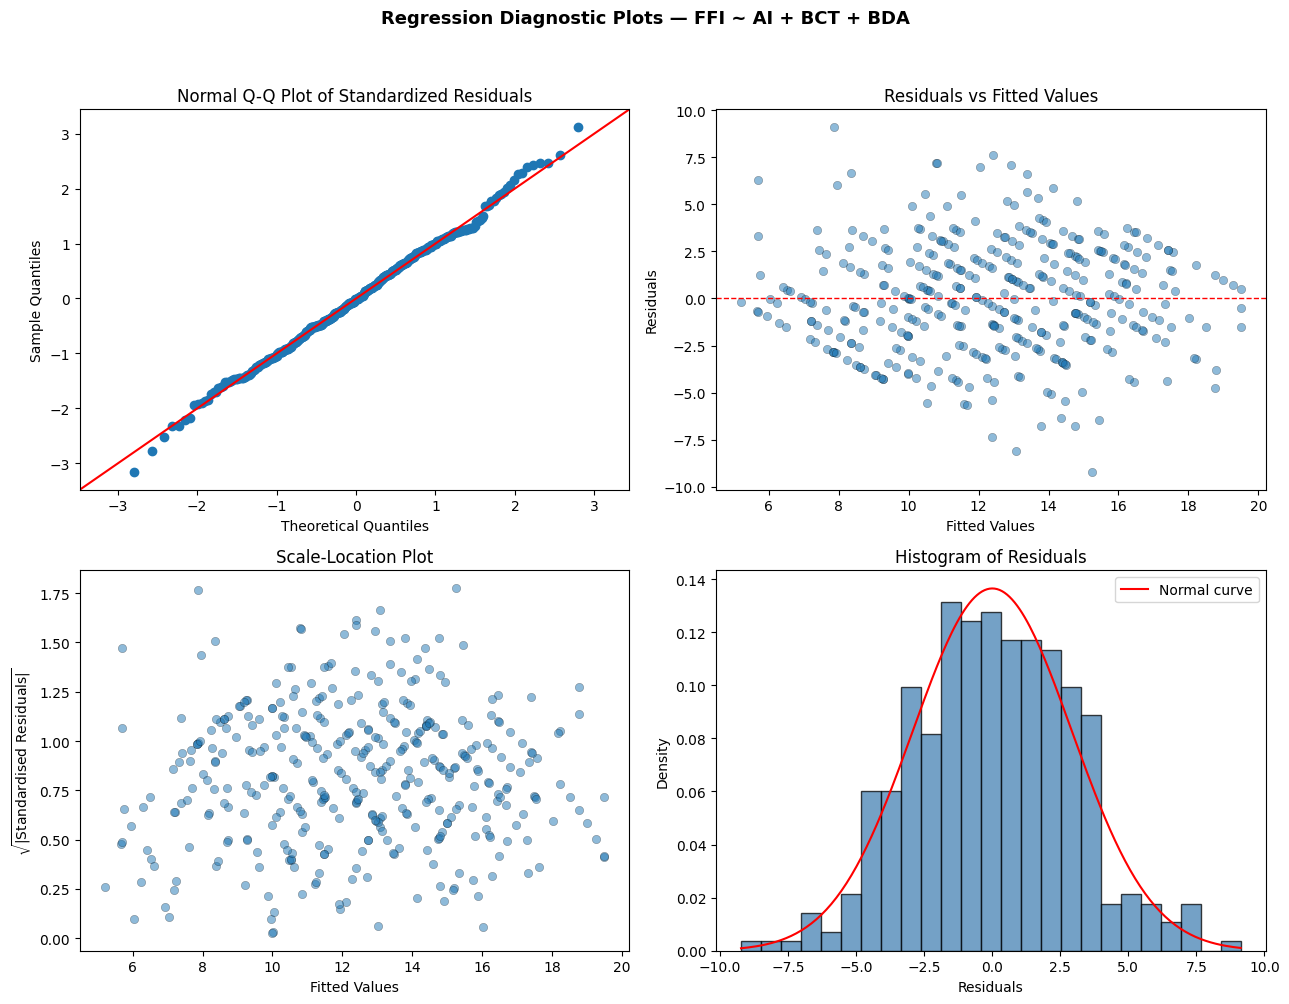


Diagnostic figure saved as: regression_diagnostics.png

                          ANALYSIS COMPLETE                           
               © R.A. Oghenerume. All Rights Reserved.                


In [8]:
import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import qqplot
resid_     = model.resid
fitted_    = model.fittedvalues
std_resid_ = resid_ / resid_.std(ddof=1)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle(
    "Regression Diagnostic Plots — FFI ~ AI + BCT + BDA",
    fontsize=13, fontweight='bold', y=1.00
)

qqplot(std_resid_, line='45', fit=True, ax=axes[0, 0])
axes[0, 0].set_title("Normal Q-Q Plot of Standardized Residuals")
axes[0, 0].set_xlabel("Theoretical Quantiles")
axes[0, 0].set_ylabel("Sample Quantiles")

axes[0, 1].scatter(fitted_, resid_, alpha=0.5,
                   edgecolor='k', linewidth=0.3)
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0, 1].set_title("Residuals vs Fitted Values")
axes[0, 1].set_xlabel("Fitted Values")
axes[0, 1].set_ylabel("Residuals")

axes[1, 0].scatter(fitted_, np.sqrt(np.abs(std_resid_)),
                   alpha=0.5, edgecolor='k', linewidth=0.3)
axes[1, 0].set_title("Scale-Location Plot")
axes[1, 0].set_xlabel("Fitted Values")
axes[1, 0].set_ylabel(r"$\sqrt{|\mathrm{Standardised\ Residuals}|}$")

axes[1, 1].hist(resid_, bins=25, edgecolor='k', alpha=0.75,
                color='steelblue', density=True)
mu_, sd_ = resid_.mean(), resid_.std(ddof=1)
xs = np.linspace(resid_.min(), resid_.max(), 200)
axes[1, 1].plot(xs, stats.norm.pdf(xs, mu_, sd_),
                color='red', linewidth=1.5, label='Normal curve')
axes[1, 1].set_title("Histogram of Residuals")
axes[1, 1].set_xlabel("Residuals")
axes[1, 1].set_ylabel("Density")
axes[1, 1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('regression_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDiagnostic figure saved as: regression_diagnostics.png")

print("\n" + "=" * 70)
print("ANALYSIS COMPLETE".center(70))
print(STATISTICIAN_BANNER.center(70))
print("=" * 70)